# ROM LFSR Item Memory
- Here we investigate and inspect how the LFSR is used to generate item-memory HVs.
- The algorithm is simple:

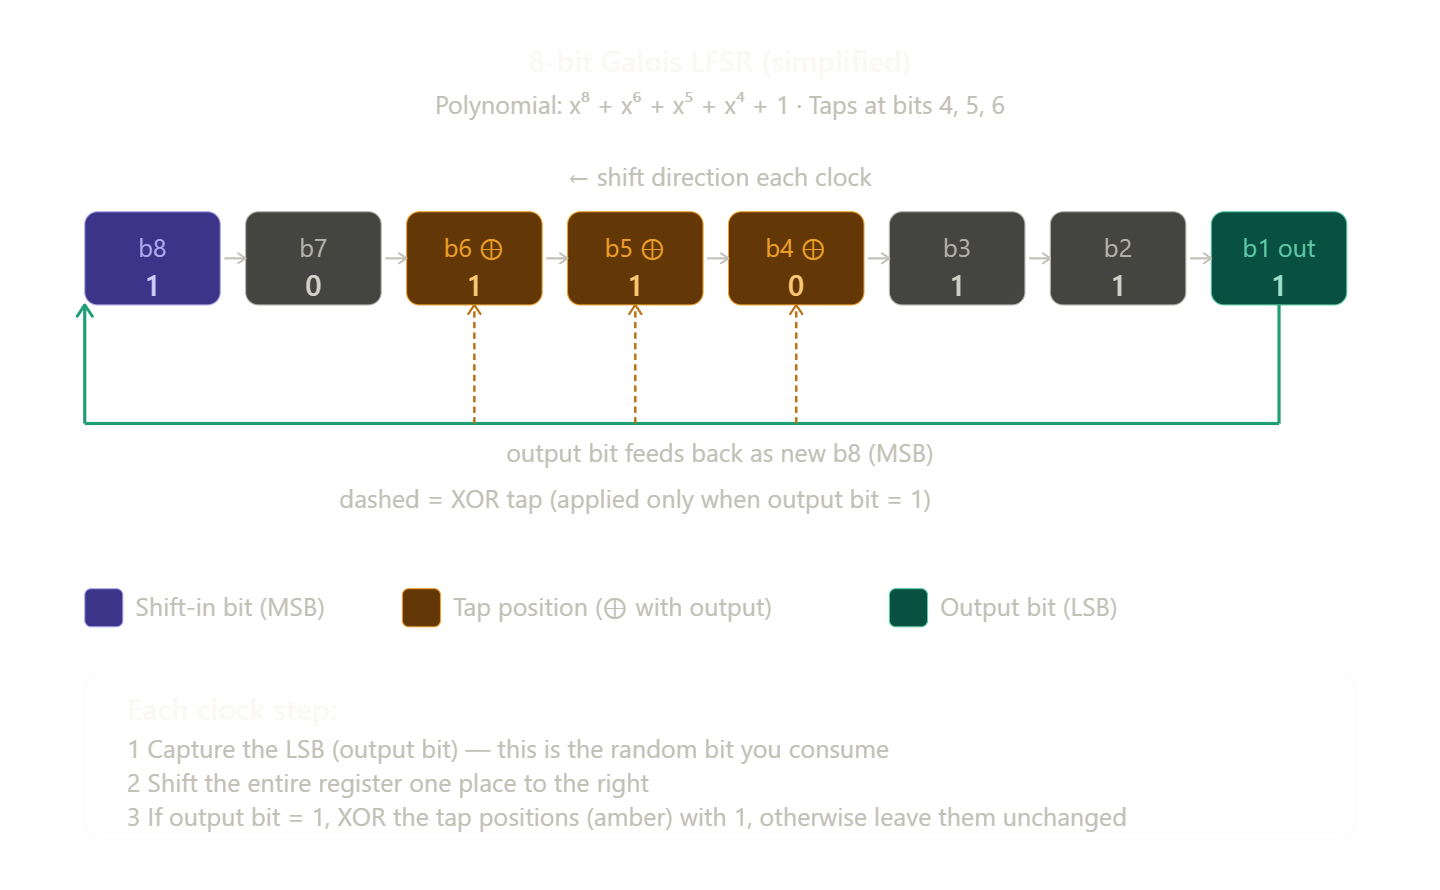

- However, take note that that was for the Galois 8-bit. We need at least 32-bit to get an infinite amount of generations.
- It is crucial that the taps are primitive, and we have Galois stuff for that:

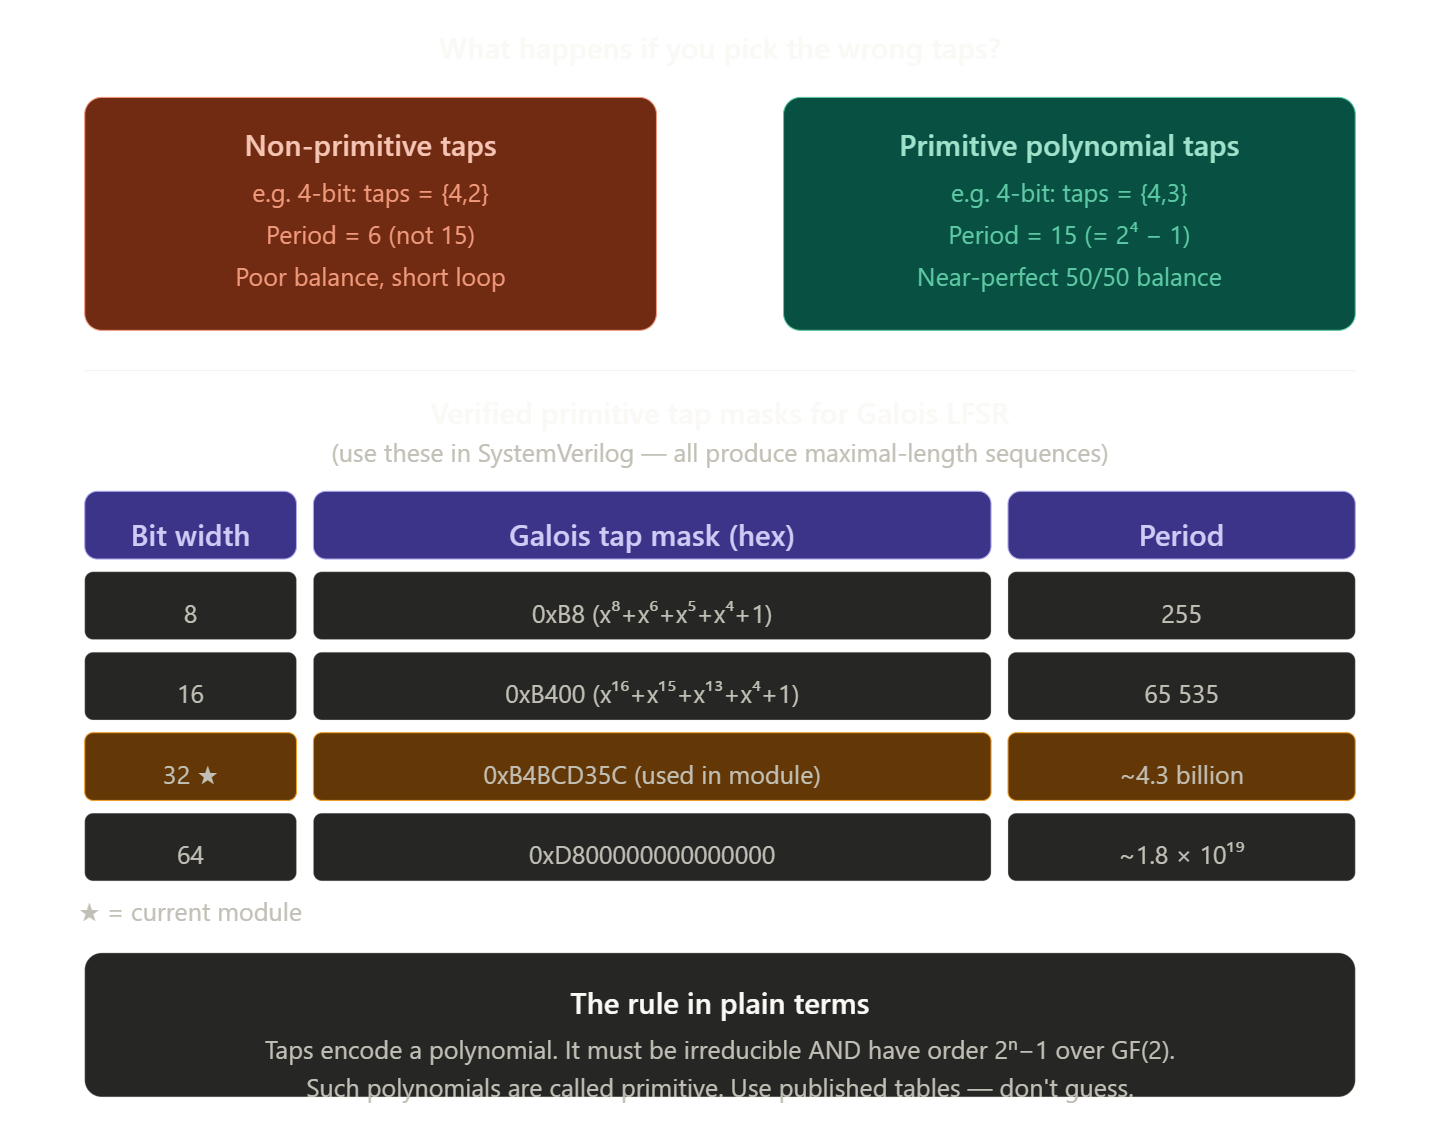

To make this happen let us do a step-by-step program on how to make this work.

In [1]:
# ---------------------------------------------------------------------------
# Importing packages
# ---------------------------------------------------------------------------
import numpy as np
from typing import Optional


# ---------------------------------------------------------------------------
# Constants (mirror the SV parameters)
# ---------------------------------------------------------------------------

MASK_32      = 0xFFFF_FFFF   # keep 32-bit arithmetic in Python ints
TAP_MASK     = 0xB4BC_D35C   # primitive polynomial — maximal-length 32-bit LFSR
KNUTH_CONST  = 0x9E37_79B9   # floor(2^32 / φ) — Knuth multiplicative hash
WARMUP_STEPS = 32            # warm-up iterations inside item_seed


Let's define a function that creates an LFSR loop
- Observe that the state is whatever the 32-bit value is.
- We do an additional 32-bit mask such that we ensure we get the 32-bits only.
- We shift right every iteration of this `lfsr_next`.

In [2]:
def lfsr_next(state: int) -> int:
    """
    One step of a 32-bit Galois LFSR.

    SV:  feedback = state[0];
         state    = {1'b0, state[31:1]};
         if (feedback) state ^= 32'hB4BCD35C;
    """
    feedback = state & 1
    state    = (state >> 1) & MASK_32
    if feedback:
        state ^= TAP_MASK
    return state

Before starting the actual LFSR we need to have a warm-up to generate an item seed.
- The `base_seed` can be any number just so that we do have a seed to replicate the "randomness".
- The `idx` or index is literally the item memory number. The catch is that we do the LFSR per every item memory we generate. So we always go through the warm-up steps everytime.
- Why is the warm-up necessary? It is to make sure we start a random state that also has, as much as possible, equal 1s and equal 0s.
- Therefore, the `item_seed` function is meant to start the generation only.

In [3]:
def item_seed(base_seed: int, idx: int) -> int:
    """
    Derive a unique, well-dispersed starting state for item `idx`.

    1. Multiply idx by the Knuth constant → scatter across 32-bit space.
    2. XOR with base_seed  → user-controlled variation.
    3. 32 LFSR warm-up steps → thoroughly mix all seed bits.

    SV:  item_seed = base_seed ^ (32'(idx) * 32'h9E3779B9);
         for (k=0; k<32; k++) item_seed = lfsr_next(item_seed);
    """
    state = (base_seed ^ ((idx * KNUTH_CONST) & MASK_32)) & MASK_32
    for _ in range(WARMUP_STEPS):
        state = lfsr_next(state)
    return state

The `gen_hv` now generates one item hypervector for a given index.
- First make sure to generate a seed.
- Then we iterate the state and get the LSB and feed it until we get all the bits of the hypervector.

In [5]:
def gen_hv(base_seed: int, idx: int, hv_dim: int) -> np.ndarray:
    """
    Generate one hypervector as a numpy array.

    Clocks the LFSR hv_dim times, collecting the LSB each step into
    a pre-allocated uint8 array.

    Returns
    -------
    np.ndarray  shape=(hv_dim,)  dtype=uint8  values ∈ {0, 1}

    SV:  for (i=0; i<HVDimension; i++) begin
             gen_hv[i] = state[0];
             state = lfsr_next(state);
         end
    """
    state = item_seed(base_seed, idx)
    bits  = np.empty(hv_dim)
    for i in range(hv_dim):
        bits[i] = state & 1          # collect LSB
        state   = lfsr_next(state)
    return bits


Let's do a few examples. You can iterate running the cell below to see how the mean of HV generation is.

In [11]:
HV_DIM    = 1024
SEED      = 42

A = gen_hv(SEED, idx=0, hv_dim=HV_DIM)
B = gen_hv(SEED, idx=1, hv_dim=HV_DIM)
C = gen_hv(SEED, idx=2, hv_dim=HV_DIM)

print("A:", A)
print("B:", B)
print("C:", C)

print("Density of A:", np.mean(A))
print("Density of B:", np.mean(B))
print("Density of C:", np.mean(C))

AXB = np.logical_xor(A, B).astype(int)
AXC = np.logical_xor(A, C).astype(int)
BXC = np.logical_xor(B, C).astype(int)

print("Density of A⊕B:", np.mean(AXB))
print("Density of A⊕C:", np.mean(AXC))
print("Density of B⊕C:", np.mean(BXC))

A: [1. 1. 0. ... 1. 0. 0.]
B: [1. 0. 1. ... 0. 1. 1.]
C: [1. 1. 1. ... 0. 1. 0.]
Density of A: 0.4990234375
Density of B: 0.5107421875
Density of C: 0.5068359375
Density of A⊕B: 0.494140625
Density of A⊕C: 0.509765625
Density of B⊕C: 0.47265625


Let's do an investigation of how it fairs with varying item memories of having 100 items. First let's lay down several useful functions.

In [13]:
# ---------------------------------------------------------------------------
# Build the full item memory
# ---------------------------------------------------------------------------

def build_item_memory(
    num_items: int = 1024,
    hv_dim:    int = 512,
    seed:      int = 0xDEAD_BEEF,
) -> np.ndarray:
    """
    Build the complete item memory.

    Equivalent to the SV generate block:
        for (genvar i = 0; i < NumTotIm; i++)
            assign item_memory[i] = gen_hv(Seed, unsigned'(i));

    Parameters
    ----------
    num_items : number of items       (SV: NumTotIm)
    hv_dim    : hypervector width     (SV: HVDimension)
    seed      : base seed             (SV: Seed parameter)

    Returns
    -------
    np.ndarray  shape=(num_items, hv_dim)  dtype=uint8  values ∈ {0, 1}

    GPU usage
    ---------
    To move to GPU after generation:
        import cupy as cp
        memory_gpu = cp.asarray(memory)

    Or replace `import numpy as np` with `import cupy as np` at the top
    of this file and generation happens on-device directly.
    """
    memory = np.empty((num_items, hv_dim), dtype=np.uint8)
    for i in range(num_items):
        memory[i] = gen_hv(seed, i, hv_dim)
    return memory

# ---------------------------------------------------------------------------
# HDV operations — fully vectorised, GPU-portable
# ---------------------------------------------------------------------------

def hamming_distance(a: np.ndarray, b: np.ndarray) -> int:
    """
    Hamming distance between two hypervectors.
    XOR then sum — works on CPU and GPU arrays alike.
    """
    return int(np.sum(a ^ b))


def hamming_matrix(memory: np.ndarray) -> np.ndarray:
    """
    Full pairwise Hamming distance matrix for all items.

    Uses the identity:  HD(a,b) = sum(a XOR b)
                                = sum(a) + sum(b) - 2 * dot(a, b)
    which reduces the problem to a single matrix multiply — very fast
    on GPU with CuPy.

    Returns
    -------
    np.ndarray  shape=(num_items, num_items)  dtype=int32
    """
    m   = memory.astype(np.int32)
    dot = m @ m.T                              # (N,D) × (D,N) → (N,N)
    diag = np.diag(dot)                        # per-row popcount
    return diag[:, None] + diag[None, :] - 2 * dot


def bundle(hvs: np.ndarray, threshold: Optional[float] = None) -> np.ndarray:
    """
    Bundle (majority vote) a set of hypervectors.

    Parameters
    ----------
    hvs       : shape (k, hv_dim) — the vectors to bundle
    threshold : fraction threshold for a 1 (default 0.5)

    Returns
    -------
    np.ndarray  shape=(hv_dim,)  dtype=uint8
    """
    t = threshold if threshold is not None else 0.5
    return (hvs.mean(axis=0) >= t).astype(np.uint8)


def bind(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """
    Bind two hypervectors (XOR — standard binary HDV binding).

    Returns
    -------
    np.ndarray  shape=(hv_dim,)  dtype=uint8
    """
    return a ^ b

# ---------------------------------------------------------------------------
# Analysis
# ---------------------------------------------------------------------------

def analyse(
    memory:       np.ndarray,
    sample_pairs: int = 500,
    rng_seed:     Optional[int] = None,
) -> dict:
    """
    Compute key statistical properties of the item memory.

    All heavy operations use vectorised numpy — fast on large memories.

    Checks
    ------
    1. Bit balance  — fraction of 1s per item  (want ~0.5)
    2. Pairwise Hamming distance  — sampled pairs  (want ~hv_dim/2)
    3. Uniqueness  — all rows are distinct

    Parameters
    ----------
    memory       : output of build_item_memory(), shape (N, D)
    sample_pairs : number of random pairs for Hamming sampling
    rng_seed     : seed for reproducible sampling

    Returns
    -------
    dict of computed stats (also printed).
    """
    n, hv_dim = memory.shape
    rng       = np.random.default_rng(rng_seed)

    # 1. Bit balance — mean over each row (vectorised)
    balance    = memory.mean(axis=1)           # shape (N,)
    mean_bal   = float(balance.mean())
    std_bal    = float(balance.std())
    min_bal    = float(balance.min())
    max_bal    = float(balance.max())

    # 2. Pairwise Hamming — sampled
    idx_a = rng.integers(0, n, size=sample_pairs)
    idx_b = rng.integers(0, n, size=sample_pairs)
    mask  = idx_a != idx_b                     # drop self-pairs
    idx_a, idx_b = idx_a[mask], idx_b[mask]

    # XOR rows then sum columns — all numpy, GPU-friendly
    dists    = (memory[idx_a] ^ memory[idx_b]).sum(axis=1)  # shape (pairs,)
    mean_hd  = float(dists.mean())
    std_hd   = float(dists.std())
    min_hd   = int(dists.min())
    max_hd   = int(dists.max())

    # 3. Uniqueness — pack bits for fast row hashing
    packed       = np.packbits(memory, axis=1)             # (N, hv_dim//8)
    unique_rows  = np.unique(packed, axis=0)
    unique_count = len(unique_rows)
    all_unique   = unique_count == n

    stats = {
        "num_items":     n,
        "hv_dim":        hv_dim,
        "dtype":         str(memory.dtype),
        "shape":         memory.shape,
        "mean_balance":  mean_bal,
        "std_balance":   std_bal,
        "min_balance":   min_bal,
        "max_balance":   max_bal,
        "ideal_balance": 0.5,
        "mean_hamming":  mean_hd,
        "std_hamming":   std_hd,
        "min_hamming":   min_hd,
        "max_hamming":   max_hd,
        "ideal_hamming": hv_dim / 2,
        "all_unique":    all_unique,
        "unique_count":  unique_count,
        "memory_bytes":  memory.nbytes,
        "sampled_pairs": int(mask.sum()),
    }

    print("=" * 56)
    print("  ROM Item Memory — LFSR Analysis (NumPy)")
    print("=" * 56)
    print(f"  Array shape  : {memory.shape}  dtype={memory.dtype}")
    print(f"  Memory usage : {memory.nbytes / 1024:.1f} KB")
    print()
    print("  Bit balance (fraction of 1s per item)")
    print(f"    ideal      :  0.5000")
    print(f"    mean       :  {mean_bal:.4f}")
    print(f"    std dev    :  {std_bal:.4f}")
    print(f"    min / max  :  {min_bal:.4f} / {max_bal:.4f}")
    print()
    print(f"  Pairwise Hamming distance  ({int(mask.sum())} sampled pairs)")
    print(f"    ideal      :  {hv_dim / 2:.1f}")
    print(f"    mean       :  {mean_hd:.2f}")
    print(f"    std dev    :  {std_hd:.2f}")
    print(f"    min / max  :  {min_hd} / {max_hd}")
    print()
    print(f"  All items unique : {all_unique}  ({unique_count}/{n})")
    print("=" * 56)

    return stats

Now let's build an item memory and investigate its contents.

In [15]:
HV_DIM    = 1024
NUM_ITEMS = 100
SEED      = 0xDEAD_BEEF

# Build item memory
memory = build_item_memory(num_items=NUM_ITEMS, hv_dim=HV_DIM, seed=SEED)

# Run full analysis
analyse(memory, sample_pairs=500, rng_seed=42)

  ROM Item Memory — LFSR Analysis (NumPy)
  Array shape  : (100, 1024)  dtype=uint8
  Memory usage : 100.0 KB

  Bit balance (fraction of 1s per item)
    ideal      :  0.5000
    mean       :  0.5021
    std dev    :  0.0171
    min / max  :  0.4629 / 0.5459

  Pairwise Hamming distance  (495 sampled pairs)
    ideal      :  512.0
    mean       :  513.04
    std dev    :  17.06
    min / max  :  460 / 557

  All items unique : True  (100/100)


{'num_items': 100,
 'hv_dim': 1024,
 'dtype': 'uint8',
 'shape': (100, 1024),
 'mean_balance': 0.502138671875,
 'std_balance': 0.01705923318854635,
 'min_balance': 0.462890625,
 'max_balance': 0.5458984375,
 'ideal_balance': 0.5,
 'mean_hamming': 513.0424242424242,
 'std_hamming': 17.056537541685515,
 'min_hamming': 460,
 'max_hamming': 557,
 'ideal_hamming': 512.0,
 'all_unique': True,
 'unique_count': 100,
 'memory_bytes': 102400,
 'sampled_pairs': 495}